In [52]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt  
import seaborn as sns

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

# # Convert string representation to actual list, checking for NaN values first
df['job_skills' ] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [53]:
df_DA_UK = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'United Kingdom')].copy()

In [54]:
df_DA_UK = df_DA_UK.dropna(subset=['salary_year_avg'])

df_DA_UK_expoded = df_DA_UK.explode('job_skills')

df_DA_UK_expoded[['salary_year_avg', 'job_skills']].head(5)

,salary_year_avg,job_skills
25994,105000.0,go
25994,105000.0,gdpr
25994,105000.0,dax
84680,105000.0,sql
98784,100500.0,sql


In [55]:
df_DA_skills =df_DA_UK_expoded.groupby('job_skills')['salary_year_avg'].agg(['count', 'mean']).sort_values('count', ascending=False)

df_DA_skills = df_DA_skills.rename(columns={'count': 'skill_count', 'mean': 'median_salary'})

DA_job_cont = len(df_DA_UK)

df_DA_skills['skill_percent'] = (df_DA_skills['skill_count'] / DA_job_cont) * 100

skill_percent = 10

df_DA_skills_in_hight_demand = df_DA_skills[df_DA_skills['skill_percent'] > skill_percent]

df_DA_skills_in_hight_demand



,skill_count,median_salary,skill_percent
job_skills,,,
sql,10,81654.550,62.50
excel,5,87700.000,31.25
python,4,86511.375,25.00
tableau,4,82375.000,25.00
sas,2,51014.000,12.50


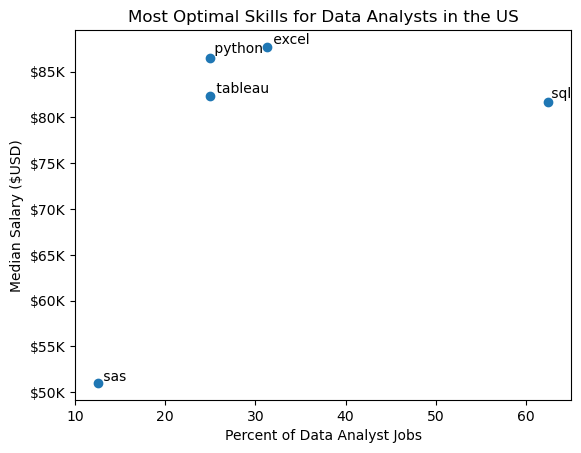

In [61]:
from adjustText import adjust_text

plt.scatter(df_DA_skills_in_hight_demand['skill_percent'], df_DA_skills_in_hight_demand['median_salary'])
plt.xlabel('Percent of Data Analyst Jobs')
plt.ylabel('Median Salary ($USD)')  # Assuming this is the label you want for y-axis
plt.title('Most Optimal Skills for Data Analysts in the US')

# Get current axes, set limits, and format axes
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))  # Example formatting y-axis

# Add labels to points and collect them in a list
texts = []
for i, txt in enumerate(df_DA_skills_in_hight_demand.index):
    texts.append(plt.text(df_DA_skills_in_hight_demand['skill_percent'].iloc[i], df_DA_skills_in_hight_demand['median_salary'].iloc[i], " " + txt))

# Adjust text to avoid overlap and add arrows
adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray'))

plt.show()